# Navigator training with adaptive visual memory, near-keyframe tolerance, and augmentation-aware robustness

This notebook extends the current training pipeline with robustness-oriented changes during log processing and model fitting:

1. **Near-keyframe tolerance**: `update_memory` is considered valid one frame before the selected keyframe, at the selected keyframe, and one frame after it.
2. **Target-switch jitter**: optional early-transition samples are created around keyframe switches to simulate slightly imperfect retracing without manual retracing.
3. **Frame-offset augmentation**: additional nearby observed frames are reused when command consistency and forward target consistency are preserved.
4. **Class-balanced feature-noise augmentation**: minority classes are oversampled inside each training fold by adding small perturbations in feature space.

The rest of the pipeline stays close to the current version:
- adaptive visual-memory generation,
- pair-dependent RGB-D feature extraction,
- leave-one-log-out cross-validation,
- model selection,
- final fit on all available data,
- metrics and visualizations.


In [1]:
import os
import json
import yaml
import joblib
import warnings
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    f1_score,
    accuracy_score,
)

import torch
import quaternion

from modules.rgbd_similarity import RGBDSimilarity
from modules.feature_based_point_cloud_registration import FeatureBasedPointCloudRegistration

try:
    from visual_memory_selector import VisualMemorySelector
except Exception as e:
    raise ImportError(
        "Could not import VisualMemorySelector from visual_memory_selector.py. "
        "Make sure that file is in the working directory."
    )

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)


/home/rodriguez/miniconda3/envs/habitat/lib/python3.9/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
/home/rodriguez/Documents/GitHub/habitat/habitat-lab/examples/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [2]:
# ------------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------------

BASE_DIR = "/home/rodriguez/Documents/GitHub/habitat/habitat-lab/manual_operation/simple_logs"

# Training VPs
TRAIN_LOGS = [
    {
        "name": "rep_dinning",
        "rgb": os.path.join(BASE_DIR, "rep_rep_dinning-0_224_20260328_084403_rgb.npy"),
        "depth": os.path.join(BASE_DIR, "rep_rep_dinning-0_224_20260328_084403_depth.npy"),
        "meta": os.path.join(BASE_DIR, "rep_rep_dinning-0_224_20260328_084403_metadata.json"),
    },
    {
        "name": "rep_wc",
        "rgb": os.path.join(BASE_DIR, "rep_rep_wc-0_224_20260329_234614_rgb.npy"),
        "depth": os.path.join(BASE_DIR, "rep_rep_wc-0_224_20260329_234614_depth.npy"),
        "meta": os.path.join(BASE_DIR, "rep_rep_wc-0_224_20260329_234614_metadata.json"),
    },
    {
        "name": "rep_kitchen-short",
        "rgb": os.path.join(BASE_DIR, "rep_rep_kitchen-0_224_20260330_110002_rgb.npy"),
        "depth": os.path.join(BASE_DIR, "rep_rep_kitchen-0_224_20260330_110002_depth.npy"),
        "meta": os.path.join(BASE_DIR, "rep_rep_kitchen-0_224_20260330_110002_metadata.json"),
    },
    {
        "name": "rep_kitchen-long",
        "rgb": os.path.join(BASE_DIR, "rep_rep_kitchen-0_224_20260330_110101_rgb.npy"),
        "depth": os.path.join(BASE_DIR, "rep_rep_kitchen-0_224_20260330_110101_depth.npy"),
        "meta": os.path.join(BASE_DIR, "rep_rep_kitchen-0_224_20260330_110101_metadata.json"),
    },
    {
        "name": "rep_waiting_room", 
        "rgb": os.path.join(BASE_DIR, "rep_rep-1_224_20260330_122612_rgb.npy"),
        "depth": os.path.join(BASE_DIR, "rep_rep-1_224_20260330_122612_depth.npy"),
        "meta": os.path.join(BASE_DIR, "rep_rep-1_224_20260330_122612_metadata.json"),
    },
    {
        "name": "rep_bed-to-lavatory", 
        "rgb": os.path.join(BASE_DIR, "rep_rep-2_224_20260330_124559_rgb.npy"),
        "depth": os.path.join(BASE_DIR, "rep_rep-2_224_20260330_124559_depth.npy"),
        "meta": os.path.join(BASE_DIR, "rep_rep-2_224_20260330_124559_metadata.json"),
    },
    {
        "name": "rep_left_bed", 
        "rgb": os.path.join(BASE_DIR, "rep_rep-2_left_bed_rgb.npy"),
        "depth": os.path.join(BASE_DIR, "rep_rep-2_left_bed_depth.npy"),
        "meta": os.path.join(BASE_DIR, "rep_rep-2_left_bed_metadata.json"),
    },
    {
        "name": "rep_right_kitchen", 
        "rgb": os.path.join(BASE_DIR, "rep_rep-4_right_kitchen_rgb.npy"),
        "depth": os.path.join(BASE_DIR, "rep_rep-4_right_kitchen_depth.npy"),
        "meta": os.path.join(BASE_DIR, "rep_rep-4_right_kitchen_metadata.json"),
    },        
]
# Previously held-out VP, now included in grouped cross-validation
TEST_LOG = {
    "name": "rep_bed_tv",
    "rgb": os.path.join(BASE_DIR, "rep_rep_bed_tv-1_224_20260329_234304_rgb.npy"),
    "depth": os.path.join(BASE_DIR, "rep_rep_bed_tv-1_224_20260329_234304_depth.npy"),
    "meta": os.path.join(BASE_DIR, "rep_rep_bed_tv-1_224_20260329_234304_metadata.json"),
}

# All logs used in cross-validation
ALL_LOGS = TRAIN_LOGS + [TEST_LOG]

# Adaptive visual-memory selection
SIGMA_K = 1.0
SAMPLE_RATE = 1

# Robust log processing
UPDATE_TOLERANCE_RADIUS = 1
ENABLE_IMPERFECT_RETRACING_PERTURBATIONS = True
EARLY_SWITCH_RADIUS = 1

# New row-level augmentation
ENABLE_FRAME_OFFSET_AUGMENTATION = True
FRAME_OFFSET_RADIUS = 1

# New feature-space augmentation (applied only to training folds / final fit)
ENABLE_CLASS_BALANCED_FEATURE_AUGMENTATION = True
AUGMENT_UP_TO_MAX_CLASS_COUNT = True
AUGMENTATION_RANDOM_STATE = 42
FEATURE_NOISE_STD_FRACTION = 0.03
TRANSLATION_NOISE_MULTIPLIER = 1.0
ROTATION_NOISE_STD = 0.01
RMSE_NOISE_MULTIPLIER = 1.0
SIM_SCORE_NOISE_MULTIPLIER = 1.0

# Feature extraction / registration config
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
FEATURE_NAV_CONF = "LightGlue"
FEATURE_MODE = "mnn"
ID_RUN_FOR_FEATURES = 999

# Path to YAML used by FeatureBasedPointCloudRegistration
EXAMPLES_CONFIG_PATH = "/home/rodriguez/Documents/GitHub/habitat/habitat-lab/examples/config.yaml"

# Output
OUTPUT_DIR = "/home/rodriguez/Documents/GitHub/habitat/habitat-lab/manual_operation/trained_navigator_outputs_cv_tolerant"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Training
RANDOM_STATE = 42
CV_STRATEGY = "LeaveOneGroupOut"

print("Device:", DEVICE)
print("Output dir:", OUTPUT_DIR)
print("CV strategy:", CV_STRATEGY)
print("Number of logs:", len(ALL_LOGS))
print("Update tolerance radius:", UPDATE_TOLERANCE_RADIUS)
print("Imperfect retracing perturbations:", ENABLE_IMPERFECT_RETRACING_PERTURBATIONS)
print("Early-switch radius:", EARLY_SWITCH_RADIUS)
print("Frame-offset augmentation:", ENABLE_FRAME_OFFSET_AUGMENTATION)
print("Frame-offset radius:", FRAME_OFFSET_RADIUS)
print("Class-balanced feature augmentation:", ENABLE_CLASS_BALANCED_FEATURE_AUGMENTATION)
print("Feature noise std fraction:", FEATURE_NOISE_STD_FRACTION)


Device: cuda
Output dir: /home/rodriguez/Documents/GitHub/habitat/habitat-lab/manual_operation/trained_navigator_outputs_cv_tolerant
CV strategy: LeaveOneGroupOut
Number of logs: 9
Update tolerance radius: 1
Imperfect retracing perturbations: True
Early-switch radius: 1
Frame-offset augmentation: True
Frame-offset radius: 1
Class-balanced feature augmentation: True
Feature noise std fraction: 0.03


In [3]:
# ------------------------------------------------------------------
# HELPERS: loading, preprocessing, feature extraction, augmentation
# ------------------------------------------------------------------

@dataclass
class LoadedLog:
    name: str
    rgb_frames: np.ndarray
    depth_frames: np.ndarray
    metadata: dict
    steps: List[dict]
    selected_indices: List[int]
    selection_result: dict


def load_single_log(log_cfg: Dict, selector: VisualMemorySelector) -> LoadedLog:
    rgb_frames = np.load(log_cfg["rgb"])
    depth_frames = np.load(log_cfg["depth"])
    with open(log_cfg["meta"], "r", encoding="utf-8") as f:
        metadata = json.load(f)
    steps = metadata["steps"]

    if len(rgb_frames) != len(steps):
        raise ValueError(f"Mismatch in {log_cfg['name']}: {len(rgb_frames)} rgb frames vs {len(steps)} metadata steps")

    selection_result = selector.select_from_arrays(
        rgb_frames=rgb_frames,
        depth_frames=depth_frames,
        sample_rate=SAMPLE_RATE,
    )
    selected_indices = selection_result["selected_real_indices"]

    return LoadedLog(
        name=log_cfg["name"],
        rgb_frames=rgb_frames,
        depth_frames=depth_frames,
        metadata=metadata,
        steps=steps,
        selected_indices=selected_indices,
        selection_result=selection_result,
    )


def build_segment_lookup(selected_indices: List[int], num_frames: int) -> List[Optional[int]]:
    selected_sorted = sorted(selected_indices)
    target_lookup: List[Optional[int]] = [None] * num_frames

    for k in range(len(selected_sorted) - 1):
        start_kf = selected_sorted[k]
        next_kf = selected_sorted[k + 1]
        for i in range(start_kf, next_kf):
            target_lookup[i] = next_kf

    last_kf = selected_sorted[-1]
    target_lookup[last_kf] = None
    return target_lookup


def build_prev_next_keyframe_maps(selected_indices: List[int]) -> Tuple[Dict[int, Optional[int]], Dict[int, Optional[int]]]:
    selected_sorted = sorted(selected_indices)
    prev_map = {}
    next_map = {}
    for i, kf in enumerate(selected_sorted):
        prev_map[kf] = selected_sorted[i - 1] if i > 0 else None
        next_map[kf] = selected_sorted[i + 1] if i < len(selected_sorted) - 1 else None
    return prev_map, next_map


def add_row(rows: List[Dict], source_log: str, raw_frame_id: int, user_command: str,
            processed_command: str, target_keyframe: Optional[int], row_type: str, step: Dict):
    rows.append({
        "source_log": source_log,
        "raw_frame_id": int(raw_frame_id),
        "user_command": user_command,
        "processed_command": processed_command,
        "target_keyframe": target_keyframe if target_keyframe is None else int(target_keyframe),
        "row_type": row_type,
        "position": step.get("position", None),
        "rotation_quaternion_wxyz": step.get("rotation_quaternion_wxyz", None),
    })


def maybe_add_frame_offset_rows(
    rows: List[Dict],
    base_rows_df: pd.DataFrame,
    log_obj: LoadedLog,
    active_target_lookup: List[Optional[int]],
    frame_offset_radius: int,
):
    if frame_offset_radius <= 0:
        return

    num_frames = len(log_obj.steps)
    step_by_frame = {int(step["frame_id"]): step for step in log_obj.steps}

    for row in base_rows_df.to_dict("records"):
        processed_command = row["processed_command"]
        if processed_command in ("update_memory", "finish"):
            continue

        source_frame = int(row["raw_frame_id"])
        source_target = row["target_keyframe"]
        if source_target is None or (isinstance(source_target, float) and np.isnan(source_target)):
            continue

        for offset in range(-frame_offset_radius, frame_offset_radius + 1):
            if offset == 0:
                continue

            neighbor_frame = source_frame + offset
            if neighbor_frame < 0 or neighbor_frame >= num_frames:
                continue

            neighbor_step = step_by_frame.get(neighbor_frame, None)
            if neighbor_step is None:
                continue

            neighbor_command = neighbor_step["user_command"]
            if neighbor_command != processed_command:
                continue

            neighbor_target = active_target_lookup[neighbor_frame]
            if neighbor_target != source_target:
                continue

            add_row(
                rows=rows,
                source_log=log_obj.name,
                raw_frame_id=neighbor_frame,
                user_command=neighbor_command,
                processed_command=processed_command,
                target_keyframe=source_target,
                row_type=f"frame_offset_aug_{offset:+d}",
                step=neighbor_step,
            )


def preprocess_log_for_training(
    log_obj: LoadedLog,
    update_tolerance_radius: int = UPDATE_TOLERANCE_RADIUS,
    enable_imperfect_retracing_perturbations: bool = ENABLE_IMPERFECT_RETRACING_PERTURBATIONS,
    early_switch_radius: int = EARLY_SWITCH_RADIUS,
    enable_frame_offset_augmentation: bool = ENABLE_FRAME_OFFSET_AUGMENTATION,
    frame_offset_radius: int = FRAME_OFFSET_RADIUS,
) -> pd.DataFrame:
    steps = log_obj.steps
    selected_indices = log_obj.selected_indices
    num_frames = len(steps)

    selected_set = set(selected_indices)
    selected_sorted = sorted(selected_indices)
    active_target_lookup = build_segment_lookup(selected_sorted, num_frames)
    prev_keyframe_map, next_keyframe_map = build_prev_next_keyframe_maps(selected_sorted)

    # Frame lookup for easy neighbor access
    step_by_frame = {int(step["frame_id"]): step for step in steps}

    rows = []

    # ------------------------------------------------------------------
    # 1) Base processed log: same logic as the current notebook
    # ------------------------------------------------------------------
    for step in steps:
        frame_id = int(step["frame_id"])
        user_command = step["user_command"]

        if frame_id in selected_set:
            # Row 1: reached selected keyframe -> update memory
            add_row(
                rows=rows,
                source_log=log_obj.name,
                raw_frame_id=frame_id,
                user_command=user_command,
                processed_command="update_memory",
                target_keyframe=frame_id,
                row_type="selected_frame_update",
                step=step,
            )

            # Row 2: duplicated row with next target if possible
            next_kf = next_keyframe_map[frame_id]
            if next_kf is not None and user_command != "finish":
                add_row(
                    rows=rows,
                    source_log=log_obj.name,
                    raw_frame_id=frame_id,
                    user_command=user_command,
                    processed_command=user_command,
                    target_keyframe=next_kf,
                    row_type="selected_frame_duplicate_next_target",
                    step=step,
                )
        else:
            target_kf = active_target_lookup[frame_id]
            add_row(
                rows=rows,
                source_log=log_obj.name,
                raw_frame_id=frame_id,
                user_command=user_command,
                processed_command=user_command,
                target_keyframe=target_kf,
                row_type="regular_motion",
                step=step,
            )

    # ------------------------------------------------------------------
    # 2) Near-keyframe tolerance: update is also valid one frame before
    #    and one frame after the selected keyframe.
    # ------------------------------------------------------------------
    if update_tolerance_radius > 0:
        for kf in selected_sorted:
            for offset in range(-update_tolerance_radius, update_tolerance_radius + 1):
                tol_frame = kf + offset
                if tol_frame < 0 or tol_frame >= num_frames:
                    continue
                if tol_frame == kf:
                    # exact selected-frame update already exists in the base logic
                    continue

                tol_step = step_by_frame.get(tol_frame, None)
                if tol_step is None:
                    continue

                offset_tag = "before" if offset < 0 else "after"
                add_row(
                    rows=rows,
                    source_log=log_obj.name,
                    raw_frame_id=tol_frame,
                    user_command=tol_step["user_command"],
                    processed_command="update_memory",
                    target_keyframe=kf,
                    row_type=f"near_keyframe_tolerance_update_{offset_tag}",
                    step=tol_step,
                )

    # ------------------------------------------------------------------
    # 3) Target-switch jitter:
    #    simulate slightly early switching to the next keyframe.
    # ------------------------------------------------------------------
    if enable_imperfect_retracing_perturbations and early_switch_radius > 0:
        for kf in selected_sorted:
            next_kf = next_keyframe_map[kf]
            if next_kf is None:
                continue

            for offset in range(1, early_switch_radius + 1):
                early_frame = kf - offset
                if early_frame < 0 or early_frame >= num_frames:
                    continue

                early_step = step_by_frame.get(early_frame, None)
                if early_step is None:
                    continue

                early_cmd = early_step["user_command"]
                if early_cmd == "finish":
                    continue

                add_row(
                    rows=rows,
                    source_log=log_obj.name,
                    raw_frame_id=early_frame,
                    user_command=early_cmd,
                    processed_command=early_cmd,
                    target_keyframe=next_kf,
                    row_type="imperfect_retracing_early_switch",
                    step=early_step,
                )

    # ------------------------------------------------------------------
    # 4) Frame-offset augmentation:
    #    reuse nearby observed frames when the command is unchanged and
    #    the active forward target remains the same.
    # ------------------------------------------------------------------
    if enable_frame_offset_augmentation and frame_offset_radius > 0:
        base_rows_df = pd.DataFrame(rows)
        maybe_add_frame_offset_rows(
            rows=rows,
            base_rows_df=base_rows_df,
            log_obj=log_obj,
            active_target_lookup=active_target_lookup,
            frame_offset_radius=frame_offset_radius,
        )

    df = pd.DataFrame(rows)

    # Deduplicate exact duplicates while preserving intentional ambiguities.
    dedup_cols = ["source_log", "raw_frame_id", "processed_command", "target_keyframe", "row_type"]
    df = df.drop_duplicates(subset=dedup_cols).reset_index(drop=True)

    return df


def normalize_label(label: str) -> str:
    if label == "update_memory":
        return "update"
    return label


def quaternion_to_wxyz(q_obj) -> Tuple[float, float, float, float]:
    if hasattr(q_obj, "w") and hasattr(q_obj, "x") and hasattr(q_obj, "y") and hasattr(q_obj, "z"):
        return float(q_obj.w), float(q_obj.x), float(q_obj.y), float(q_obj.z)
    arr = quaternion.as_float_array(q_obj)
    return float(arr[0]), float(arr[1]), float(arr[2]), float(arr[3])


def load_feature_registration_config() -> dict:
    with open(EXAMPLES_CONFIG_PATH, "r") as f:
        return yaml.safe_load(f)


def build_feature_extractors(device: str):
    config = load_feature_registration_config()

    rgbd_similarity = RGBDSimilarity(device=device)

    feature_registration = FeatureBasedPointCloudRegistration(
        config=config,
        device=device,
        id_run=ID_RUN_FOR_FEATURES,
        feature_nav_conf=FEATURE_NAV_CONF,
        feature_mode=FEATURE_MODE,
        topological_map=None,
        manual_operation=False,
    )

    return rgbd_similarity, feature_registration


def extract_features_from_processed_df(
    processed_df: pd.DataFrame,
    loaded_logs: Dict[str, LoadedLog],
    rgbd_similarity: RGBDSimilarity,
    feature_registration: FeatureBasedPointCloudRegistration,
) -> pd.DataFrame:
    rows_out = []

    iterable = processed_df.to_dict("records")
    for row in tqdm(iterable, total=len(iterable), desc="Extracting pair-dependent features"):
        label = normalize_label(row["processed_command"])
        target_kf = row["target_keyframe"]

        # Skip terminal rows or rows without a valid target keyframe
        if label == "finish":
            continue
        if target_kf is None or (isinstance(target_kf, float) and np.isnan(target_kf)):
            continue

        log_obj = loaded_logs[row["source_log"]]
        raw_frame_id = int(row["raw_frame_id"])
        target_kf = int(target_kf)

        o_color = log_obj.rgb_frames[raw_frame_id]
        o_depth = log_obj.depth_frames[raw_frame_id]
        k_color = log_obj.rgb_frames[target_kf]
        k_depth = log_obj.depth_frames[target_kf]

        try:
            sim_score = float(rgbd_similarity.compute_image_similarity(o_color, o_depth, k_color, k_depth))

            bot_lost, est_quaternion, rmse, est_t_source_target, _ = feature_registration.compute_relative_pose(
                o_color,
                o_depth,
                k_color,
                k_depth,
            )

            qw, qx, qy, qz = quaternion_to_wxyz(est_quaternion)
            tx, ty, tz = [float(x) for x in np.asarray(est_t_source_target).reshape(-1)[:3]]
            rmse = float(rmse)

            rows_out.append({
                "source_log": row["source_log"],
                "raw_frame_id": raw_frame_id,
                "target_keyframe": target_kf,
                "user_command": row["user_command"],
                "processed_command": row["processed_command"],
                "label": label,
                "row_type": row["row_type"],
                "bot_lost": bool(bot_lost),
                "rmse": rmse,
                "tx": tx,
                "ty": ty,
                "tz": tz,
                "qw": qw,
                "qx": qx,
                "qy": qy,
                "qz": qz,
                "sim_score": sim_score,
            })
        except Exception as e:
            rows_out.append({
                "source_log": row["source_log"],
                "raw_frame_id": raw_frame_id,
                "target_keyframe": target_kf,
                "user_command": row["user_command"],
                "processed_command": row["processed_command"],
                "label": label,
                "row_type": row["row_type"],
                "bot_lost": None,
                "rmse": np.nan,
                "tx": np.nan,
                "ty": np.nan,
                "tz": np.nan,
                "qw": np.nan,
                "qx": np.nan,
                "qy": np.nan,
                "qz": np.nan,
                "sim_score": np.nan,
                "error": str(e),
            })

    feat_df = pd.DataFrame(rows_out)
    return feat_df


def renormalize_quaternion_block(df: pd.DataFrame) -> pd.DataFrame:
    quat_cols = ["qw", "qx", "qy", "qz"]
    if not set(quat_cols).issubset(df.columns):
        return df

    q = df[quat_cols].to_numpy(dtype=np.float64)
    norms = np.linalg.norm(q, axis=1, keepdims=True)
    norms = np.where(norms < 1e-12, 1.0, norms)
    q = q / norms
    df.loc[:, quat_cols] = q.astype(np.float32)
    return df


def augment_training_dataframe(
    train_df: pd.DataFrame,
    feature_cols: List[str],
    random_state: int = RANDOM_STATE,
    enable_class_balanced_feature_augmentation: bool = ENABLE_CLASS_BALANCED_FEATURE_AUGMENTATION,
) -> pd.DataFrame:
    train_df = train_df.copy().reset_index(drop=True)
    train_df["is_augmented"] = False
    train_df["augmentation_type"] = "original"

    if not enable_class_balanced_feature_augmentation:
        return train_df

    class_counts = train_df["label"].value_counts()
    if class_counts.empty:
        return train_df

    target_count = int(class_counts.max()) if AUGMENT_UP_TO_MAX_CLASS_COUNT else int(np.ceil(class_counts.mean()))
    rng = np.random.RandomState(random_state)

    # Noise scales derived from the current training fold only.
    eps = 1e-8
    base_std = train_df[feature_cols].std(ddof=0).fillna(0.0)
    noise_scales = {
        "rmse": max(float(base_std.get("rmse", 0.0)) * FEATURE_NOISE_STD_FRACTION * RMSE_NOISE_MULTIPLIER, eps),
        "tx": max(float(base_std.get("tx", 0.0)) * FEATURE_NOISE_STD_FRACTION * TRANSLATION_NOISE_MULTIPLIER, eps),
        "ty": max(float(base_std.get("ty", 0.0)) * FEATURE_NOISE_STD_FRACTION * TRANSLATION_NOISE_MULTIPLIER, eps),
        "tz": max(float(base_std.get("tz", 0.0)) * FEATURE_NOISE_STD_FRACTION * TRANSLATION_NOISE_MULTIPLIER, eps),
        "qw": max(ROTATION_NOISE_STD, eps),
        "qx": max(ROTATION_NOISE_STD, eps),
        "qy": max(ROTATION_NOISE_STD, eps),
        "qz": max(ROTATION_NOISE_STD, eps),
        "sim_score": max(float(base_std.get("sim_score", 0.0)) * FEATURE_NOISE_STD_FRACTION * SIM_SCORE_NOISE_MULTIPLIER, eps),
    }

    aug_parts = [train_df]

    for label, count in class_counts.items():
        if count >= target_count:
            continue

        n_to_add = target_count - int(count)
        source_rows = train_df[train_df["label"] == label]
        sampled = source_rows.sample(
            n=n_to_add,
            replace=True,
            random_state=random_state + int(count) + len(label),
        ).copy()

        for col in feature_cols:
            scale = noise_scales.get(col, eps)
            sampled[col] = sampled[col].astype(np.float64) + rng.normal(loc=0.0, scale=scale, size=len(sampled))

        sampled = renormalize_quaternion_block(sampled)
        sampled["is_augmented"] = True
        sampled["augmentation_type"] = "class_balanced_feature_noise"
        sampled["row_type"] = sampled["row_type"].astype(str) + "|class_balanced_feature_noise"

        aug_parts.append(sampled)

    aug_df = pd.concat(aug_parts, ignore_index=True)
    return aug_df.reset_index(drop=True)


In [4]:
# ------------------------------------------------------------------
# LOAD LOGS AND GENERATE VISUAL MEMORIES
# ------------------------------------------------------------------

selector = VisualMemorySelector(sigma_k=SIGMA_K)

all_loaded_logs = {}
for log_cfg in ALL_LOGS:
    loaded = load_single_log(log_cfg, selector)
    all_loaded_logs[loaded.name] = loaded
    print(f"Loaded log: {loaded.name}")
    print(f"  frames: {len(loaded.rgb_frames)}")
    print(f"  selected keyframes: {loaded.selected_indices}")
    print(f"  threshold: {loaded.selection_result['threshold']:.4f}")


Computing similarity matrix: 100%|██████████| 266/266 [00:08<00:00, 32.03it/s] 


Loaded log: rep_dinning
  frames: 266
  selected keyframes: [0, 2, 4, 6, 9, 13, 17, 20, 23, 27, 29, 31, 33, 34, 36, 39, 41, 42, 44, 46, 47, 49, 51, 52, 53, 55, 57, 58, 59, 61, 62, 65, 67, 69, 71, 73, 75, 78, 80, 82, 86, 90, 95, 98, 100, 102, 105, 108, 112, 114, 116, 118, 120, 121, 122, 123, 124, 126, 127, 129, 132, 134, 136, 138, 140, 142, 144, 146, 148, 150, 151, 152, 154, 156, 158, 161, 164, 166, 169, 172, 175, 177, 179, 181, 183, 187, 189, 191, 193, 195, 197, 199, 201, 203, 205, 207, 209, 211, 213, 216, 218, 220, 222, 224, 226, 228, 230, 231, 233, 234, 236, 238, 240, 242, 245, 246, 247, 248, 249, 252, 254, 256, 257, 258, 259, 260, 262, 265]
  threshold: 0.9399


Computing similarity matrix: 100%|██████████| 298/298 [00:10<00:00, 28.65it/s] 


Loaded log: rep_wc
  frames: 298
  selected keyframes: [0, 3, 6, 8, 9, 11, 13, 15, 16, 17, 19, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 32, 34, 38, 41, 43, 45, 47, 49, 51, 53, 55, 57, 58, 61, 63, 65, 68, 70, 72, 74, 76, 78, 80, 82, 84, 85, 86, 87, 89, 91, 93, 95, 98, 100, 102, 104, 107, 109, 111, 113, 115, 117, 119, 121, 123, 125, 127, 129, 132, 135, 137, 139, 141, 143, 146, 150, 154, 156, 158, 161, 162, 166, 168, 170, 172, 175, 177, 179, 182, 184, 186, 188, 190, 192, 194, 196, 198, 200, 202, 204, 206, 208, 210, 212, 214, 217, 220, 225, 231, 235, 239, 242, 244, 247, 250, 253, 255, 257, 259, 263, 266, 269, 272, 275, 278, 280, 281, 283, 285, 287, 290, 292, 295, 297]
  threshold: 0.9346


Computing similarity matrix: 100%|██████████| 151/151 [00:02<00:00, 56.88it/s] 


...

Loaded log: rep_left_bed
  frames: 134
  selected keyframes: [0, 2, 3, 5, 6, 8, 10, 12, 15, 18, 20, 22, 24, 26, 29, 31, 33, 35, 37, 40, 42, 44, 46, 48, 50, 52, 53, 56, 58, 60, 61, 62, 63, 64, 65, 67, 69, 71, 73, 74, 76, 79, 82, 83, 85, 87, 89, 91, 94, 96, 98, 101, 104, 106, 108, 109, 111, 113, 115, 117, 120, 123, 125, 127, 128, 130, 132, 133]
  threshold: 0.9350


Computing similarity matrix: 100%|██████████| 323/323 [00:12<00:00, 26.29it/s] 


Loaded log: rep_right_kitchen
  frames: 323
  selected keyframes: [0, 2, 5, 7, 9, 10, 13, 15, 17, 20, 23, 26, 28, 31, 33, 34, 36, 39, 41, 44, 46, 48, 49, 51, 53, 54, 56, 57, 58, 59, 61, 64, 66, 68, 70, 72, 75, 78, 80, 82, 84, 85, 86, 89, 90, 91, 93, 95, 97, 98, 99, 100, 102, 104, 105, 106, 108, 110, 111, 113, 114, 115, 117, 119, 121, 122, 124, 125, 126, 127, 129, 131, 133, 135, 137, 139, 141, 143, 145, 147, 149, 151, 153, 155, 157, 159, 161, 163, 165, 168, 170, 172, 174, 176, 178, 180, 181, 182, 184, 186, 189, 191, 193, 195, 197, 199, 201, 203, 205, 207, 208, 210, 211, 214, 217, 218, 221, 223, 228, 231, 234, 238, 240, 241, 244, 247, 250, 254, 256, 258, 260, 262, 264, 267, 269, 271, 273, 275, 277, 279, 281, 284, 286, 289, 292, 295, 298, 301, 303, 305, 306, 309, 312, 314, 316, 318, 320, 322]
  threshold: 0.9432


Computing similarity matrix: 100%|██████████| 225/225 [00:06<00:00, 37.47it/s]

Loaded log: rep_bed_tv
  frames: 225
  selected keyframes: [0, 2, 4, 6, 7, 9, 11, 13, 16, 18, 19, 21, 23, 26, 28, 30, 32, 34, 35, 37, 40, 43, 46, 48, 50, 52, 54, 56, 59, 61, 63, 64, 66, 68, 69, 71, 72, 73, 74, 75, 79, 81, 82, 84, 86, 87, 88, 89, 90, 93, 97, 101, 103, 105, 107, 111, 114, 116, 118, 120, 122, 124, 125, 127, 129, 130, 132, 134, 136, 138, 139, 141, 143, 145, 146, 147, 149, 151, 153, 155, 157, 160, 163, 166, 170, 173, 177, 180, 183, 187, 191, 195, 198, 202, 205, 207, 210, 212, 214, 217, 219, 223, 224]
  threshold: 0.9384


In [5]:
# ------------------------------------------------------------------
# VISUAL-MEMORY SUMMARY TABLE
# ------------------------------------------------------------------

summary_rows = []
for name, log_obj in all_loaded_logs.items():
    summary_rows.append({
        "log": name,
        "num_frames": len(log_obj.rgb_frames),
        "num_keyframes": len(log_obj.selected_indices),
        "threshold": log_obj.selection_result["threshold"],
        "mu_d1": log_obj.selection_result["mu"],
        "sigma_d1": log_obj.selection_result["sigma"],
    })

selection_summary_df = pd.DataFrame(summary_rows).sort_values("log").reset_index(drop=True)
display(selection_summary_df)


,log,num_frames,num_keyframes,threshold,mu_d1,sigma_d1
0,rep_bed-to-lavatory,116,51,0.928842,0.945744,0.016903
1,rep_bed_tv,225,103,0.938441,0.952792,0.014351
2,rep_dinning,266,128,0.939857,0.951678,0.011821
3,rep_kitchen-long,254,124,0.947405,0.958646,0.011240
4,rep_kitchen-short,151,73,0.946981,0.957751,0.010770
5,rep_left_bed,134,68,0.935022,0.946697,0.011675
6,rep_right_kitchen,323,158,0.943192,0.954633,0.011441
7,rep_waiting_room,150,74,0.940616,0.951041,0.010425
8,rep_wc,298,135,0.934632,0.949984,0.015353


In [6]:
# ------------------------------------------------------------------
# PREPROCESS LOGS WITH NEAR-KEYFRAME TOLERANCE + AUGMENTED ROBUSTNESS
# ------------------------------------------------------------------

processed_all_dfs = []
for name, log_obj in all_loaded_logs.items():
    df = preprocess_log_for_training(log_obj)
    processed_all_dfs.append(df)
    print(f"Processed log {name}: shape={df.shape}")

processed_all_df = pd.concat(processed_all_dfs, ignore_index=True)

print("Combined processed shape:", processed_all_df.shape)
display(processed_all_df.head(20))


Processed log rep_dinning: shape=(1078, 8)
Processed log rep_wc: shape=(1195, 8)
Processed log rep_kitchen-short: shape=(587, 8)
Processed log rep_kitchen-long: shape=(1013, 8)
Processed log rep_waiting_room: shape=(584, 8)
Processed log rep_bed-to-lavatory: shape=(398, 8)
Processed log rep_left_bed: shape=(532, 8)
Processed log rep_right_kitchen: shape=(1301, 8)
Processed log rep_bed_tv: shape=(897, 8)
Combined processed shape: (7585, 8)


,source_log,raw_frame_id,user_command,processed_command,target_keyframe,row_type,position,rotation_quaternion_wxyz
0,rep_dinning,0,forward,update_memory,0,selected_frame_update,"[0.6751305460929871, 0.07244700193405151, -3.2...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
1,rep_dinning,0,forward,forward,2,selected_frame_duplicate_next_target,"[0.6751305460929871, 0.07244700193405151, -3.2...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
2,rep_dinning,1,forward,forward,2,regular_motion,"[0.6560497879981995, 0.07244700193405151, -3.1...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
3,rep_dinning,2,forward,update_memory,2,selected_frame_update,"[0.6369690299034119, 0.07244700193405151, -3.0...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
4,rep_dinning,2,forward,forward,4,selected_frame_duplicate_next_target,"[0.6369690299034119, 0.07244700193405151, -3.0...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
5,rep_dinning,3,forward,forward,4,regular_motion,"[0.6178882718086243, 0.07244700193405151, -2.9...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
6,rep_dinning,4,forward,update_memory,4,selected_frame_update,"[0.5988075137138367, 0.07244700193405151, -2.8...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
7,rep_dinning,4,forward,forward,6,selected_frame_duplicate_next_target,"[0.5988075137138367, 0.07244700193405151, -2.8...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
8,rep_dinning,5,forward,forward,6,regular_motion,"[0.5797267556190491, 0.07244700193405151, -2.7...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
9,rep_dinning,6,forward,update_memory,6,selected_frame_update,"[0.5606459975242615, 0.07244700193405151, -2.6...","[0.09584498405456543, 0.0, 0.9953963160514832,..."


In [7]:
# ------------------------------------------------------------------
# PREPROCESSED LABEL COUNTS (BEFORE FEATURE EXTRACTION)
# ------------------------------------------------------------------

print("Processed command counts:")
display(processed_all_df["processed_command"].value_counts(dropna=False).to_frame("count"))

print("Counts by source log and processed command:")
display(
    processed_all_df.groupby(["source_log", "processed_command"]).size().unstack(fill_value=0)
)

print("Counts by row type:")
display(processed_all_df["row_type"].value_counts(dropna=False).to_frame("count"))


Processed command counts:


,count
processed_command,
update_memory,2724
forward,2125
right,1822
left,914


Counts by source log and processed command:


processed_command,forward,left,right,update_memory
source_log,,,,
rep_bed-to-lavatory,96,151,0,151
rep_bed_tv,344,127,119,307
rep_dinning,350,248,98,382
rep_kitchen-long,229,52,362,370
rep_kitchen-short,131,8,231,217
rep_left_bed,111,214,5,202
rep_right_kitchen,208,7,614,472
rep_waiting_room,200,56,108,220
rep_wc,456,51,285,403


Counts by row type:


,count
row_type,
frame_offset_aug_+1,1358
regular_motion,1003
selected_frame_update,914
selected_frame_duplicate_next_target,905
near_keyframe_tolerance_update_after,905
near_keyframe_tolerance_update_before,905
imperfect_retracing_early_switch,896
frame_offset_aug_-1,699


In [8]:
# ------------------------------------------------------------------
# BUILD FEATURE EXTRACTORS
# ------------------------------------------------------------------

rgbd_similarity, feature_registration = build_feature_extractors(DEVICE)
print("Feature extractors ready.")

Feature extractors ready.


In [9]:
# ------------------------------------------------------------------
# EXTRACT FEATURES FOR ALL LOGS
# ------------------------------------------------------------------

all_feat_df = extract_features_from_processed_df(
    processed_df=processed_all_df,
    loaded_logs=all_loaded_logs,
    rgbd_similarity=rgbd_similarity,
    feature_registration=feature_registration,
)

print("Feature table shape:", all_feat_df.shape)
display(all_feat_df.head(20))


Extracting pair-dependent features: 100%|██████████| 7585/7585 [22:44<00:00,  5.56it/s]

Feature table shape: (7585, 17)


,source_log,raw_frame_id,target_keyframe,user_command,processed_command,label,row_type,bot_lost,rmse,tx,ty,tz,qw,qx,qy,qz,sim_score
0,rep_dinning,0,0,forward,update_memory,update,selected_frame_update,False,7.971944e-16,-1.110223e-16,7.771561e-16,-8.881784e-16,-1.000000,7.793685e-17,-2.010076e-16,-9.748082e-17,1.000000
1,rep_dinning,0,2,forward,forward,forward,selected_frame_duplicate_next_target,False,2.253966e-01,-1.104259e-02,2.779756e-02,1.710790e-01,-0.999988,3.831845e-03,2.790258e-03,1.237332e-03,0.932823
2,rep_dinning,1,2,forward,forward,forward,regular_motion,False,3.282183e-01,-5.060988e-03,6.372766e-03,1.106206e-01,0.999999,-1.198777e-03,1.591713e-04,5.196332e-04,0.950073
3,rep_dinning,2,2,forward,update_memory,update,selected_frame_update,False,8.112449e-16,4.440892e-16,-6.661338e-16,0.000000e+00,-1.000000,-0.000000e+00,2.964003e-16,2.879095e-16,1.000000
4,rep_dinning,2,4,forward,forward,forward,selected_frame_duplicate_next_target,False,3.497174e-01,-7.351410e-02,1.119213e-03,1.754399e-01,-0.999957,1.179809e-03,9.028461e-03,-1.601200e-03,0.934189
5,rep_dinning,3,4,forward,forward,forward,regular_motion,False,3.007303e-01,8.243455e-03,-4.912237e-03,1.229194e-01,0.999999,5.139054e-04,1.587474e-03,1.882942e-04,0.947703
6,rep_dinning,4,4,forward,update_memory,update,selected_frame_update,False,9.682328e-16,1.110223e-16,1.387779e-15,-4.440892e-16,-1.000000,1.003338e-16,2.841699e-16,5.554516e-17,1.000000
7,rep_dinning,4,6,forward,forward,forward,selected_frame_duplicate_next_target,False,3.790081e-01,-6.389276e-02,5.824745e-03,1.431000e-01,-0.999953,1.716753e-03,9.470675e-03,-1.208730e-03,0.915995
8,rep_dinning,5,6,forward,forward,forward,regular_motion,False,1.823603e-01,6.845055e-04,-4.691751e-03,9.659763e-02,-0.999997,-9.386327e-04,9.077370e-04,1.901982e-03,0.944848
9,rep_dinning,6,6,forward,update_memory,update,selected_frame_update,False,4.527719e-16,-2.220446e-16,3.608225e-16,0.000000e+00,1.000000,-0.000000e+00,-1.068240e-16,2.487997e-17,1.000000


In [10]:
print("Raw extracted feature shape:", all_feat_df.shape)
display(all_feat_df.head(20))
cols_to_check = ["rmse","tx","ty","tz","qw","qx","qy","qz","sim_score"]
if "error" in all_feat_df.columns:
    cols_to_check.append("error")

print(all_feat_df[cols_to_check].isna().sum())

if "error" in all_feat_df.columns:
    display(all_feat_df["error"].fillna("NO_ERROR").value_counts().head(20))


Raw extracted feature shape: (7585, 17)


,source_log,raw_frame_id,target_keyframe,user_command,processed_command,label,row_type,bot_lost,rmse,tx,ty,tz,qw,qx,qy,qz,sim_score
0,rep_dinning,0,0,forward,update_memory,update,selected_frame_update,False,7.971944e-16,-1.110223e-16,7.771561e-16,-8.881784e-16,-1.000000,7.793685e-17,-2.010076e-16,-9.748082e-17,1.000000
1,rep_dinning,0,2,forward,forward,forward,selected_frame_duplicate_next_target,False,2.253966e-01,-1.104259e-02,2.779756e-02,1.710790e-01,-0.999988,3.831845e-03,2.790258e-03,1.237332e-03,0.932823
2,rep_dinning,1,2,forward,forward,forward,regular_motion,False,3.282183e-01,-5.060988e-03,6.372766e-03,1.106206e-01,0.999999,-1.198777e-03,1.591713e-04,5.196332e-04,0.950073
3,rep_dinning,2,2,forward,update_memory,update,selected_frame_update,False,8.112449e-16,4.440892e-16,-6.661338e-16,0.000000e+00,-1.000000,-0.000000e+00,2.964003e-16,2.879095e-16,1.000000
4,rep_dinning,2,4,forward,forward,forward,selected_frame_duplicate_next_target,False,3.497174e-01,-7.351410e-02,1.119213e-03,1.754399e-01,-0.999957,1.179809e-03,9.028461e-03,-1.601200e-03,0.934189
5,rep_dinning,3,4,forward,forward,forward,regular_motion,False,3.007303e-01,8.243455e-03,-4.912237e-03,1.229194e-01,0.999999,5.139054e-04,1.587474e-03,1.882942e-04,0.947703
6,rep_dinning,4,4,forward,update_memory,update,selected_frame_update,False,9.682328e-16,1.110223e-16,1.387779e-15,-4.440892e-16,-1.000000,1.003338e-16,2.841699e-16,5.554516e-17,1.000000
7,rep_dinning,4,6,forward,forward,forward,selected_frame_duplicate_next_target,False,3.790081e-01,-6.389276e-02,5.824745e-03,1.431000e-01,-0.999953,1.716753e-03,9.470675e-03,-1.208730e-03,0.915995
8,rep_dinning,5,6,forward,forward,forward,regular_motion,False,1.823603e-01,6.845055e-04,-4.691751e-03,9.659763e-02,-0.999997,-9.386327e-04,9.077370e-04,1.901982e-03,0.944848
9,rep_dinning,6,6,forward,update_memory,update,selected_frame_update,False,4.527719e-16,-2.220446e-16,3.608225e-16,0.000000e+00,1.000000,-0.000000e+00,-1.068240e-16,2.487997e-17,1.000000


rmse         0
tx           0
ty           0
tz           0
qw           0
qx           0
qy           0
qz           0
sim_score    0
dtype: int64


In [11]:
print(processed_all_df.shape)
display(processed_all_df.head(20))
print(processed_all_df["processed_command"].value_counts(dropna=False))
print(processed_all_df["target_keyframe"].isna().sum(), "rows with target_keyframe NaN")
display(processed_all_df[processed_all_df["target_keyframe"].isna()].head(20))


(7585, 8)


,source_log,raw_frame_id,user_command,processed_command,target_keyframe,row_type,position,rotation_quaternion_wxyz
0,rep_dinning,0,forward,update_memory,0,selected_frame_update,"[0.6751305460929871, 0.07244700193405151, -3.2...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
1,rep_dinning,0,forward,forward,2,selected_frame_duplicate_next_target,"[0.6751305460929871, 0.07244700193405151, -3.2...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
2,rep_dinning,1,forward,forward,2,regular_motion,"[0.6560497879981995, 0.07244700193405151, -3.1...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
3,rep_dinning,2,forward,update_memory,2,selected_frame_update,"[0.6369690299034119, 0.07244700193405151, -3.0...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
4,rep_dinning,2,forward,forward,4,selected_frame_duplicate_next_target,"[0.6369690299034119, 0.07244700193405151, -3.0...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
5,rep_dinning,3,forward,forward,4,regular_motion,"[0.6178882718086243, 0.07244700193405151, -2.9...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
6,rep_dinning,4,forward,update_memory,4,selected_frame_update,"[0.5988075137138367, 0.07244700193405151, -2.8...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
7,rep_dinning,4,forward,forward,6,selected_frame_duplicate_next_target,"[0.5988075137138367, 0.07244700193405151, -2.8...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
8,rep_dinning,5,forward,forward,6,regular_motion,"[0.5797267556190491, 0.07244700193405151, -2.7...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
9,rep_dinning,6,forward,update_memory,6,selected_frame_update,"[0.5606459975242615, 0.07244700193405151, -2.6...","[0.09584498405456543, 0.0, 0.9953963160514832,..."


processed_command
update_memory    2724
forward          2125
right            1822
left              914
Name: count, dtype: int64
0 rows with target_keyframe NaN


,source_log,raw_frame_id,user_command,processed_command,target_keyframe,row_type,position,rotation_quaternion_wxyz


In [12]:
display(processed_all_df[["source_log", "raw_frame_id","processed_command","target_keyframe","row_type"]].tail(30))


,source_log,raw_frame_id,processed_command,target_keyframe,row_type
7555,rep_bed_tv,132,forward,134,frame_offset_aug_+1
7556,rep_bed_tv,134,forward,136,frame_offset_aug_+1
7557,rep_bed_tv,136,forward,138,frame_offset_aug_+1
7558,rep_bed_tv,138,forward,139,frame_offset_aug_+1
7559,rep_bed_tv,139,forward,141,frame_offset_aug_+1
7560,rep_bed_tv,141,forward,143,frame_offset_aug_+1
7561,rep_bed_tv,143,forward,145,frame_offset_aug_+1
7562,rep_bed_tv,145,forward,146,frame_offset_aug_+1
7563,rep_bed_tv,146,forward,147,frame_offset_aug_+1
7564,rep_bed_tv,147,forward,149,frame_offset_aug_+1


In [13]:
print("processed_all_df shape:", processed_all_df.shape)


processed_all_df shape: (7585, 8)


In [14]:
# ------------------------------------------------------------------
# FEATURE TABLE SUMMARY BY SOURCE LOG
# ------------------------------------------------------------------

display(
    all_feat_df.groupby("source_log").size().to_frame("num_feature_rows")
)


,num_feature_rows
source_log,
rep_bed-to-lavatory,398
rep_bed_tv,897
rep_dinning,1078
rep_kitchen-long,1013
rep_kitchen-short,587
rep_left_bed,532
rep_right_kitchen,1301
rep_waiting_room,584
rep_wc,1195


In [15]:
print(all_feat_df.shape)
print(all_feat_df.columns.tolist())
display(all_feat_df.head(10))
if "error" in all_feat_df.columns:
    display(all_feat_df["error"].value_counts(dropna=False).head(20))


(7585, 17)
['source_log', 'raw_frame_id', 'target_keyframe', 'user_command', 'processed_command', 'label', 'row_type', 'bot_lost', 'rmse', 'tx', 'ty', 'tz', 'qw', 'qx', 'qy', 'qz', 'sim_score']


,source_log,raw_frame_id,target_keyframe,user_command,processed_command,label,row_type,bot_lost,rmse,tx,ty,tz,qw,qx,qy,qz,sim_score
0,rep_dinning,0,0,forward,update_memory,update,selected_frame_update,False,7.971944e-16,-1.110223e-16,7.771561e-16,-8.881784e-16,-1.000000,7.793685e-17,-2.010076e-16,-9.748082e-17,1.000000
1,rep_dinning,0,2,forward,forward,forward,selected_frame_duplicate_next_target,False,2.253966e-01,-1.104259e-02,2.779756e-02,1.710790e-01,-0.999988,3.831845e-03,2.790258e-03,1.237332e-03,0.932823
2,rep_dinning,1,2,forward,forward,forward,regular_motion,False,3.282183e-01,-5.060988e-03,6.372766e-03,1.106206e-01,0.999999,-1.198777e-03,1.591713e-04,5.196332e-04,0.950073
3,rep_dinning,2,2,forward,update_memory,update,selected_frame_update,False,8.112449e-16,4.440892e-16,-6.661338e-16,0.000000e+00,-1.000000,-0.000000e+00,2.964003e-16,2.879095e-16,1.000000
4,rep_dinning,2,4,forward,forward,forward,selected_frame_duplicate_next_target,False,3.497174e-01,-7.351410e-02,1.119213e-03,1.754399e-01,-0.999957,1.179809e-03,9.028461e-03,-1.601200e-03,0.934189
5,rep_dinning,3,4,forward,forward,forward,regular_motion,False,3.007303e-01,8.243455e-03,-4.912237e-03,1.229194e-01,0.999999,5.139054e-04,1.587474e-03,1.882942e-04,0.947703
6,rep_dinning,4,4,forward,update_memory,update,selected_frame_update,False,9.682328e-16,1.110223e-16,1.387779e-15,-4.440892e-16,-1.000000,1.003338e-16,2.841699e-16,5.554516e-17,1.000000
7,rep_dinning,4,6,forward,forward,forward,selected_frame_duplicate_next_target,False,3.790081e-01,-6.389276e-02,5.824745e-03,1.431000e-01,-0.999953,1.716753e-03,9.470675e-03,-1.208730e-03,0.915995
8,rep_dinning,5,6,forward,forward,forward,regular_motion,False,1.823603e-01,6.845055e-04,-4.691751e-03,9.659763e-02,-0.999997,-9.386327e-04,9.077370e-04,1.901982e-03,0.944848
9,rep_dinning,6,6,forward,update_memory,update,selected_frame_update,False,4.527719e-16,-2.220446e-16,3.608225e-16,0.000000e+00,1.000000,-0.000000e+00,-1.068240e-16,2.487997e-17,1.000000


In [16]:
# ------------------------------------------------------------------
# CLEAN FEATURE TABLE AND SAVE IT
# ------------------------------------------------------------------

feature_cols = ["rmse", "tx", "ty", "tz", "qw", "qx", "qy", "qz", "sim_score"]

all_feat_df = all_feat_df.dropna(subset=feature_cols + ["label"]).reset_index(drop=True)

all_feat_csv = os.path.join(OUTPUT_DIR, "all_features.csv")
all_feat_df.to_csv(all_feat_csv, index=False)

print("Clean feature shape:", all_feat_df.shape)
print("Saved:")
print(all_feat_csv)


Clean feature shape: (7585, 17)
Saved:
/home/rodriguez/Documents/GitHub/habitat/habitat-lab/manual_operation/trained_navigator_outputs_cv_tolerant/all_features.csv


In [17]:
# ------------------------------------------------------------------
# FEATURE-TABLE LABEL COUNTS
# ------------------------------------------------------------------

print("Label counts:")
display(all_feat_df["label"].value_counts().to_frame("count"))

print("Label counts by source log:")
display(
    all_feat_df.groupby(["source_log", "label"]).size().unstack(fill_value=0)
)


Label counts:


,count
label,
update,2724
forward,2125
right,1822
left,914


Label counts by source log:


label,forward,left,right,update
source_log,,,,
rep_bed-to-lavatory,96,151,0,151
rep_bed_tv,344,127,119,307
rep_dinning,350,248,98,382
rep_kitchen-long,229,52,362,370
rep_kitchen-short,131,8,231,217
rep_left_bed,111,214,5,202
rep_right_kitchen,208,7,614,472
rep_waiting_room,200,56,108,220
rep_wc,456,51,285,403


In [18]:
print("all_feat_df shape:", all_feat_df.shape)
display(all_feat_df.head())


all_feat_df shape: (7585, 17)


,source_log,raw_frame_id,target_keyframe,user_command,processed_command,label,row_type,bot_lost,rmse,tx,ty,tz,qw,qx,qy,qz,sim_score
0,rep_dinning,0,0,forward,update_memory,update,selected_frame_update,False,7.971944e-16,-1.110223e-16,7.771561e-16,-8.881784e-16,-1.000000,7.793685e-17,-2.010076e-16,-9.748082e-17,1.000000
1,rep_dinning,0,2,forward,forward,forward,selected_frame_duplicate_next_target,False,2.253966e-01,-1.104259e-02,2.779756e-02,1.710790e-01,-0.999988,3.831845e-03,2.790258e-03,1.237332e-03,0.932823
2,rep_dinning,1,2,forward,forward,forward,regular_motion,False,3.282183e-01,-5.060988e-03,6.372766e-03,1.106206e-01,0.999999,-1.198777e-03,1.591713e-04,5.196332e-04,0.950073
3,rep_dinning,2,2,forward,update_memory,update,selected_frame_update,False,8.112449e-16,4.440892e-16,-6.661338e-16,0.000000e+00,-1.000000,-0.000000e+00,2.964003e-16,2.879095e-16,1.000000
4,rep_dinning,2,4,forward,forward,forward,selected_frame_duplicate_next_target,False,3.497174e-01,-7.351410e-02,1.119213e-03,1.754399e-01,-0.999957,1.179809e-03,9.028461e-03,-1.601200e-03,0.934189


In [19]:
# ------------------------------------------------------------------
# PREPARE GROUPED CROSS-VALIDATION
# ------------------------------------------------------------------

X_all = all_feat_df[feature_cols].values.astype(np.float32)
y_all = all_feat_df["label"].values
groups = all_feat_df["source_log"].values

logo = LeaveOneGroupOut()
fold_plan = []
for fold_id, (_, val_idx) in enumerate(logo.split(X_all, y_all, groups), start=1):
    heldout_logs = sorted(set(groups[val_idx]))
    fold_plan.append({
        "fold": fold_id,
        "heldout_log": heldout_logs[0],
        "num_val_rows": int(len(val_idx)),
    })

fold_plan_df = pd.DataFrame(fold_plan)
print("Total original samples:", len(X_all))
print("Total folds           :", len(fold_plan_df))
display(fold_plan_df)


Total original samples: 7585
Total folds           : 9


,fold,heldout_log,num_val_rows
0,1,rep_bed-to-lavatory,398
1,2,rep_bed_tv,897
2,3,rep_dinning,1078
3,4,rep_kitchen-long,1013
4,5,rep_kitchen-short,587
5,6,rep_left_bed,532
6,7,rep_right_kitchen,1301
7,8,rep_waiting_room,584
8,9,rep_wc,1195


In [20]:
# ------------------------------------------------------------------
# TRAIN MLP GRID WITH LEAVE-ONE-LOG-OUT CROSS-VALIDATION
# ------------------------------------------------------------------

from itertools import product

param_grid = {
    "activation": ["relu", "tanh"],
    "solver": ["adam"],  # keep this focused first; SGD was clearly worse
    "hidden_layer_sizes": [
        (64,),
        (100,),
        (128,),
        (64, 32),
        (128, 64),
        (128, 64, 32),
    ],
    "alpha": [1e-5, 1e-4, 1e-3],
    "learning_rate_init": [1e-4, 5e-4, 1e-3],
}

candidate_configs = []
for activation, solver, hidden_layer_sizes, alpha, learning_rate_init in product(
    param_grid["activation"],
    param_grid["solver"],
    param_grid["hidden_layer_sizes"],
    param_grid["alpha"],
    param_grid["learning_rate_init"],
):
    cfg = {
        "name": (
            f"{activation}_{solver}"
            f"__hls-{str(hidden_layer_sizes).replace(' ', '')}"
            f"__alpha-{alpha}"
            f"__lr-{learning_rate_init}"
        ),
        "activation": activation,
        "solver": solver,
        "hidden_layer_sizes": hidden_layer_sizes,
        "alpha": alpha,
        "learning_rate_init": learning_rate_init,
    }
    candidate_configs.append(cfg)

print(f"Total candidate configs: {len(candidate_configs)}")

all_classes = np.array(sorted(pd.Series(y_all).unique()))
class_to_global_idx = {cls: i for i, cls in enumerate(all_classes)}

cv_summary_rows = []
cv_artifacts = {}

for cfg_id, cfg in enumerate(candidate_configs, start=1):
    print("=" * 80)
    print(f"Evaluating config {cfg_id}/{len(candidate_configs)}: {cfg['name']}")
    print("=" * 80)

    fold_rows = []
    oof_pred = np.empty(len(y_all), dtype=object)
    oof_prob = np.full((len(y_all), len(all_classes)), np.nan, dtype=np.float32)

    for fold_id, (train_idx, val_idx) in enumerate(logo.split(X_all, y_all, groups), start=1):
        heldout_log = sorted(set(groups[val_idx]))[0]

        train_df_fold = all_feat_df.iloc[train_idx].copy().reset_index(drop=True)
        val_df_fold = all_feat_df.iloc[val_idx].copy().reset_index(drop=True)

        train_df_aug = augment_training_dataframe(
            train_df=train_df_fold,
            feature_cols=feature_cols,
            random_state=AUGMENTATION_RANDOM_STATE + fold_id,
            enable_class_balanced_feature_augmentation=ENABLE_CLASS_BALANCED_FEATURE_AUGMENTATION,
        )

        X_train = train_df_aug[feature_cols].values.astype(np.float32)
        y_train = train_df_aug["label"].values
        X_val = val_df_fold[feature_cols].values.astype(np.float32)
        y_val = val_df_fold["label"].values

        scaler_fold = StandardScaler()
        X_train_s = scaler_fold.fit_transform(X_train)
        X_val_s = scaler_fold.transform(X_val)

        clf = MLPClassifier(
            hidden_layer_sizes=cfg["hidden_layer_sizes"],
            activation=cfg["activation"],
            solver=cfg["solver"],
            alpha=cfg["alpha"],
            learning_rate_init=cfg["learning_rate_init"],
            max_iter=600,
            random_state=RANDOM_STATE,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=20,
        )

        clf.fit(X_train_s, y_train)

        val_pred = clf.predict(X_val_s)
        val_prob = clf.predict_proba(X_val_s)

        oof_pred[val_idx] = val_pred
        for local_col, cls in enumerate(clf.classes_):
            global_col = class_to_global_idx[cls]
            oof_prob[val_idx, global_col] = val_prob[:, local_col]

        fold_row = {
            "fold": fold_id,
            "heldout_log": heldout_log,
            "n_train_original": int(len(train_df_fold)),
            "n_train_augmented": int(len(train_df_aug)),
            "n_val": int(len(val_idx)),
            "n_iter": int(clf.n_iter_),
            "accuracy": accuracy_score(y_val, val_pred),
            "balanced_accuracy": balanced_accuracy_score(y_val, val_pred),
            "macro_f1": f1_score(y_val, val_pred, average="macro"),
            "weighted_f1": f1_score(y_val, val_pred, average="weighted"),
            "final_loss": float(clf.loss_),
        }
        fold_rows.append(fold_row)
        print(fold_row)

    fold_results_df = pd.DataFrame(fold_rows)
    oof_accuracy = accuracy_score(y_all, oof_pred)
    oof_bal_acc = balanced_accuracy_score(y_all, oof_pred)
    oof_macro_f1 = f1_score(y_all, oof_pred, average="macro")
    oof_weighted_f1 = f1_score(y_all, oof_pred, average="weighted")

    cv_summary_rows.append({
        "name": cfg["name"],
        "activation": cfg["activation"],
        "solver": cfg["solver"],
        "hidden_layer_sizes": str(cfg["hidden_layer_sizes"]),
        "alpha": cfg["alpha"],
        "learning_rate_init": cfg["learning_rate_init"],
        "mean_accuracy": fold_results_df["accuracy"].mean(),
        "mean_balanced_accuracy": fold_results_df["balanced_accuracy"].mean(),
        "mean_macro_f1": fold_results_df["macro_f1"].mean(),
        "mean_weighted_f1": fold_results_df["weighted_f1"].mean(),
        "mean_n_train_original": fold_results_df["n_train_original"].mean(),
        "mean_n_train_augmented": fold_results_df["n_train_augmented"].mean(),
        "std_macro_f1": fold_results_df["macro_f1"].std(ddof=0),
        "oof_accuracy": oof_accuracy,
        "oof_balanced_accuracy": oof_bal_acc,
        "oof_macro_f1": oof_macro_f1,
        "oof_weighted_f1": oof_weighted_f1,
    })

    cv_artifacts[cfg["name"]] = {
        "config": cfg,
        "fold_results_df": fold_results_df,
        "oof_pred": oof_pred.copy(),
        "oof_prob": oof_prob.copy(),
    }

results_df = (
    pd.DataFrame(cv_summary_rows)
    .sort_values(
        ["oof_macro_f1", "oof_balanced_accuracy", "mean_macro_f1", "std_macro_f1"],
        ascending=[False, False, False, True]
    )
    .reset_index(drop=True)
)

display(results_df)


Total candidate configs: 108
Evaluating config 1/108: relu_adam__hls-(64,)__alpha-1e-05__lr-0.0001
{'fold': 1, 'heldout_log': 'rep_bed-to-lavatory', 'n_train_original': 7187, 'n_train_augmented': 10292, 'n_val': 398, 'n_iter': 121, 'accuracy': 0.7185929648241206, 'balanced_accuracy': 0.7312591979396615, 'macro_f1': 0.5561846795404208, 'weighted_f1': 0.7400869197524166, 'final_loss': 0.36467012784323527}
{'fold': 2, 'heldout_log': 'rep_bed_tv', 'n_train_original': 6688, 'n_train_augmented': 9668, 'n_val': 897, 'n_iter': 132, 'accuracy': 0.7926421404682275, 'balanced_accuracy': 0.7901857804591768, 'macro_f1': 0.7837590290842766, 'weighted_f1': 0.7901572014296088, 'final_loss': 0.3693488040832442}
{'fold': 3, 'heldout_log': 'rep_dinning', 'n_train_original': 6507, 'n_train_augmented': 9368, 'n_val': 1078, 'n_iter': 73, 'accuracy': 0.774582560296846, 'balanced_accuracy': 0.8076321911977086, 'macro_f1': 0.7608476154744963, 'weighted_f1': 0.7705452137002317, 'final_loss': 0.421540357883763}


,name,activation,solver,hidden_layer_sizes,alpha,learning_rate_init,mean_accuracy,mean_balanced_accuracy,mean_macro_f1,mean_weighted_f1,mean_n_train_original,mean_n_train_augmented,std_macro_f1,oof_accuracy,oof_balanced_accuracy,oof_macro_f1,oof_weighted_f1
0,"relu_adam__hls-(128,64,32)__alpha-0.001__lr-0....",relu,adam,"(128, 64, 32)",0.00100,0.0001,0.774844,0.766866,0.705991,0.778798,6742.222222,9685.333333,0.084734,0.781938,0.789904,0.780300,0.778539
1,"relu_adam__hls-(128,64)__alpha-1e-05__lr-0.0001",relu,adam,"(128, 64)",0.00001,0.0001,0.773432,0.767928,0.704019,0.777416,6742.222222,9685.333333,0.083942,0.780092,0.792874,0.779706,0.776708
2,"relu_adam__hls-(128,64)__alpha-0.001__lr-0.0001",relu,adam,"(128, 64)",0.00100,0.0001,0.773241,0.767855,0.703857,0.777223,6742.222222,9685.333333,0.083796,0.779960,0.792918,0.779629,0.776572
3,"tanh_adam__hls-(128,64,32)__alpha-0.0001__lr-0...",tanh,adam,"(128, 64, 32)",0.00010,0.0005,0.773128,0.767241,0.713664,0.777512,6742.222222,9685.333333,0.095819,0.783256,0.782234,0.779485,0.780282
4,"relu_adam__hls-(128,64)__alpha-0.0001__lr-0.0001",relu,adam,"(128, 64)",0.00010,0.0001,0.773241,0.768522,0.703468,0.777083,6742.222222,9685.333333,0.083511,0.779960,0.793172,0.779381,0.776458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,"tanh_adam__hls-(100,)__alpha-0.0001__lr-0.0001",tanh,adam,"(100,)",0.00010,0.0001,0.758543,0.764522,0.680960,0.762277,6742.222222,9685.333333,0.078018,0.762426,0.798886,0.762233,0.756632
104,"tanh_adam__hls-(100,)__alpha-0.001__lr-0.0001",tanh,adam,"(100,)",0.00100,0.0001,0.758543,0.764522,0.680960,0.762277,6742.222222,9685.333333,0.078018,0.762426,0.798886,0.762233,0.756632
105,"tanh_adam__hls-(64,32)__alpha-0.0001__lr-0.0001",tanh,adam,"(64, 32)",0.00010,0.0001,0.759254,0.745377,0.685873,0.763654,6742.222222,9685.333333,0.087557,0.765063,0.785561,0.762094,0.759999
106,"tanh_adam__hls-(64,32)__alpha-0.001__lr-0.0001",tanh,adam,"(64, 32)",0.00100,0.0001,0.759254,0.745377,0.685873,0.763654,6742.222222,9685.333333,0.087557,0.765063,0.785561,0.762094,0.759999


In [21]:
# ------------------------------------------------------------------
# SELECT BEST MODEL BASED ON GROUPED CROSS-VALIDATION
# ------------------------------------------------------------------

best_model_name = results_df.iloc[0]["name"]
best_cfg = cv_artifacts[best_model_name]["config"]
best_cv_fold_results_df = cv_artifacts[best_model_name]["fold_results_df"]
best_oof_pred = cv_artifacts[best_model_name]["oof_pred"]
best_oof_prob = cv_artifacts[best_model_name]["oof_prob"]

print("Best model:", best_model_name)
print(results_df.iloc[0])
display(best_cv_fold_results_df)


Best model: relu_adam__hls-(128,64,32)__alpha-0.001__lr-0.0001
name                      relu_adam__hls-(128,64,32)__alpha-0.001__lr-0....
activation                                                             relu
solver                                                                 adam
hidden_layer_sizes                                            (128, 64, 32)
alpha                                                                 0.001
learning_rate_init                                                   0.0001
mean_accuracy                                                      0.774844
mean_balanced_accuracy                                             0.766866
mean_macro_f1                                                      0.705991
mean_weighted_f1                                                   0.778798
mean_n_train_original                                           6742.222222
mean_n_train_augmented                                          9685.333333
std_macro_f1             

,fold,heldout_log,n_train_original,n_train_augmented,n_val,n_iter,accuracy,balanced_accuracy,macro_f1,weighted_f1,final_loss
0,1,rep_bed-to-lavatory,7187,10292,398,69,0.723618,0.736939,0.561603,0.746490,0.305110
1,2,rep_bed_tv,6688,9668,897,167,0.807135,0.806453,0.800653,0.803868,0.280642
2,3,rep_dinning,6507,9368,1078,78,0.770872,0.787733,0.761246,0.771599,0.313271
3,4,rep_kitchen-long,6572,9416,1013,49,0.786772,0.809599,0.754531,0.784305,0.350461
4,5,rep_kitchen-short,6998,10028,587,112,0.797274,0.701371,0.691546,0.796262,0.295400
5,6,rep_left_bed,7053,10088,532,90,0.721805,0.798994,0.615125,0.736266,0.304053
6,7,rep_right_kitchen,6284,9008,1301,79,0.776326,0.689689,0.609129,0.785397,0.304439
7,8,rep_waiting_room,7001,10016,584,81,0.770548,0.780031,0.762917,0.768607,0.304846
8,9,rep_wc,6390,9284,1195,112,0.819247,0.790989,0.797169,0.816392,0.301108


In [22]:
# ------------------------------------------------------------------
# FIT BEST MODEL ON ALL DATA AND SAVE MODEL / SCALER / METADATA
# ------------------------------------------------------------------

all_fit_df = augment_training_dataframe(
    train_df=all_feat_df,
    feature_cols=feature_cols,
    random_state=AUGMENTATION_RANDOM_STATE,
    enable_class_balanced_feature_augmentation=ENABLE_CLASS_BALANCED_FEATURE_AUGMENTATION,
)

X_all_fit = all_fit_df[feature_cols].values.astype(np.float32)
y_all_fit = all_fit_df["label"].values

scaler = StandardScaler()
X_all_s = scaler.fit_transform(X_all_fit)

best_model = MLPClassifier(
    hidden_layer_sizes=best_cfg["hidden_layer_sizes"],
    activation=best_cfg["activation"],
    solver=best_cfg["solver"],
    alpha=best_cfg["alpha"],
    learning_rate_init=best_cfg["learning_rate_init"],
    max_iter=600,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
)
best_model.fit(X_all_s, y_all_fit)

model_path = os.path.join(OUTPUT_DIR, f"navigator_{best_model_name}_cv.joblib")
scaler_path = os.path.join(OUTPUT_DIR, f"scaler_{best_model_name}_cv.joblib")
results_path = os.path.join(OUTPUT_DIR, "cv_model_selection_results.csv")
fold_results_path = os.path.join(OUTPUT_DIR, f"{best_model_name}_fold_results.csv")
config_path = os.path.join(OUTPUT_DIR, "training_config_cv.json")
all_fit_csv = os.path.join(OUTPUT_DIR, "all_features_augmented_for_final_fit.csv")

joblib.dump(best_model, model_path)
joblib.dump(scaler, scaler_path)
results_df.to_csv(results_path, index=False)
best_cv_fold_results_df.to_csv(fold_results_path, index=False)
all_fit_df.to_csv(all_fit_csv, index=False)

training_config = {
    "all_logs": ALL_LOGS,
    "sigma_k": SIGMA_K,
    "sample_rate": SAMPLE_RATE,
    "update_tolerance_radius": UPDATE_TOLERANCE_RADIUS,
    "enable_imperfect_retracing_perturbations": ENABLE_IMPERFECT_RETRACING_PERTURBATIONS,
    "early_switch_radius": EARLY_SWITCH_RADIUS,
    "enable_frame_offset_augmentation": ENABLE_FRAME_OFFSET_AUGMENTATION,
    "frame_offset_radius": FRAME_OFFSET_RADIUS,
    "enable_class_balanced_feature_augmentation": ENABLE_CLASS_BALANCED_FEATURE_AUGMENTATION,
    "feature_noise_std_fraction": FEATURE_NOISE_STD_FRACTION,
    "translation_noise_multiplier": TRANSLATION_NOISE_MULTIPLIER,
    "rotation_noise_std": ROTATION_NOISE_STD,
    "rmse_noise_multiplier": RMSE_NOISE_MULTIPLIER,
    "sim_score_noise_multiplier": SIM_SCORE_NOISE_MULTIPLIER,
    "feature_cols": feature_cols,
    "cv_strategy": CV_STRATEGY,
    "best_model_name": best_model_name,
    "best_model_config": {
        "name": best_cfg["name"],
        "activation": best_cfg["activation"],
        "solver": best_cfg["solver"],
        "hidden_layer_sizes": list(best_cfg["hidden_layer_sizes"]),
        "alpha": best_cfg["alpha"],
        "learning_rate_init": best_cfg["learning_rate_init"],
    },
    "n_original_final_fit_rows": int(len(all_feat_df)),
    "n_augmented_final_fit_rows": int(len(all_fit_df)),
}
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(training_config, f, indent=2, ensure_ascii=False)

print("Final-fit original rows :", len(all_feat_df))
print("Final-fit augmented rows:", len(all_fit_df))
print("Saved:")
print(model_path)
print(scaler_path)
print(results_path)
print(fold_results_path)
print(all_fit_csv)
print(config_path)


Final-fit original rows : 7585
Final-fit augmented rows: 10896
Saved:
/home/rodriguez/Documents/GitHub/habitat/habitat-lab/manual_operation/trained_navigator_outputs_cv_tolerant/navigator_relu_adam__hls-(128,64,32)__alpha-0.001__lr-0.0001_cv.joblib
/home/rodriguez/Documents/GitHub/habitat/habitat-lab/manual_operation/trained_navigator_outputs_cv_tolerant/scaler_relu_adam__hls-(128,64,32)__alpha-0.001__lr-0.0001_cv.joblib
/home/rodriguez/Documents/GitHub/habitat/habitat-lab/manual_operation/trained_navigator_outputs_cv_tolerant/cv_model_selection_results.csv
/home/rodriguez/Documents/GitHub/habitat/habitat-lab/manual_operation/trained_navigator_outputs_cv_tolerant/relu_adam__hls-(128,64,32)__alpha-0.001__lr-0.0001_fold_results.csv
/home/rodriguez/Documents/GitHub/habitat/habitat-lab/manual_operation/trained_navigator_outputs_cv_tolerant/all_features_augmented_for_final_fit.csv
/home/rodriguez/Documents/GitHub/habitat/habitat-lab/manual_operation/trained_navigator_outputs_cv_tolerant/tra

In [23]:
# ------------------------------------------------------------------
# TRAINING CURVES OF FINAL MODEL FIT ON ALL DATA
# ------------------------------------------------------------------

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(best_model.loss_curve_, marker="o")
plt.title(f"Loss curve - {best_model_name}")
plt.xlabel("Iteration")
plt.ylabel("Training loss")
plt.grid(True)

plt.subplot(1, 2, 2)
if hasattr(best_model, "validation_scores_") and best_model.validation_scores_ is not None:
    plt.plot(best_model.validation_scores_, marker="o")
    plt.title(f"Internal validation score curve - {best_model_name}")
    plt.xlabel("Iteration")
    plt.ylabel("Validation score")
    plt.grid(True)
else:
    plt.text(0.5, 0.5, "No validation_scores_ available", ha="center", va="center")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [24]:
# ------------------------------------------------------------------
# OUT-OF-FOLD CROSS-VALIDATION PERFORMANCE OF BEST MODEL
# ------------------------------------------------------------------

print("Out-of-fold CV metrics")
print("Accuracy          :", round(accuracy_score(y_all, best_oof_pred), 4))
print("Balanced accuracy :", round(balanced_accuracy_score(y_all, best_oof_pred), 4))
print("Macro F1          :", round(f1_score(y_all, best_oof_pred, average='macro'), 4))
print("Weighted F1       :", round(f1_score(y_all, best_oof_pred, average='weighted'), 4))
print()
print(classification_report(y_all, best_oof_pred))


Out-of-fold CV metrics
Accuracy          : 0.7819
Balanced accuracy : 0.7899
Macro F1          : 0.7803
Weighted F1       : 0.7785

              precision    recall  f1-score   support

     forward       0.78      0.88      0.82      2125
        left       0.76      0.75      0.76       914
       right       0.76      0.87      0.81      1822
      update       0.82      0.65      0.73      2724

    accuracy                           0.78      7585
   macro avg       0.78      0.79      0.78      7585
weighted avg       0.79      0.78      0.78      7585



In [25]:
# ------------------------------------------------------------------
# PER-FOLD PERFORMANCE OF BEST MODEL
# ------------------------------------------------------------------

cv_metrics = {
    "accuracy": accuracy_score(y_all, best_oof_pred),
    "balanced_accuracy": balanced_accuracy_score(y_all, best_oof_pred),
    "macro_f1": f1_score(y_all, best_oof_pred, average="macro"),
    "weighted_f1": f1_score(y_all, best_oof_pred, average="weighted"),
}

print("Best-model CV metrics")
for k, v in cv_metrics.items():
    print(f"{k:18s}: {v:.4f}")
print()
display(best_cv_fold_results_df)

cv_metrics_path = os.path.join(OUTPUT_DIR, "best_model_cv_metrics.json")
with open(cv_metrics_path, "w", encoding="utf-8") as f:
    json.dump(cv_metrics, f, indent=2)
print("Saved CV metrics to:", cv_metrics_path)


Best-model CV metrics
accuracy          : 0.7819
balanced_accuracy : 0.7899
macro_f1          : 0.7803
weighted_f1       : 0.7785



,fold,heldout_log,n_train_original,n_train_augmented,n_val,n_iter,accuracy,balanced_accuracy,macro_f1,weighted_f1,final_loss
0,1,rep_bed-to-lavatory,7187,10292,398,69,0.723618,0.736939,0.561603,0.746490,0.305110
1,2,rep_bed_tv,6688,9668,897,167,0.807135,0.806453,0.800653,0.803868,0.280642
2,3,rep_dinning,6507,9368,1078,78,0.770872,0.787733,0.761246,0.771599,0.313271
3,4,rep_kitchen-long,6572,9416,1013,49,0.786772,0.809599,0.754531,0.784305,0.350461
4,5,rep_kitchen-short,6998,10028,587,112,0.797274,0.701371,0.691546,0.796262,0.295400
5,6,rep_left_bed,7053,10088,532,90,0.721805,0.798994,0.615125,0.736266,0.304053
6,7,rep_right_kitchen,6284,9008,1301,79,0.776326,0.689689,0.609129,0.785397,0.304439
7,8,rep_waiting_room,7001,10016,584,81,0.770548,0.780031,0.762917,0.768607,0.304846
8,9,rep_wc,6390,9284,1195,112,0.819247,0.790989,0.797169,0.816392,0.301108


Saved CV metrics to: /home/rodriguez/Documents/GitHub/habitat/habitat-lab/manual_operation/trained_navigator_outputs_cv_tolerant/best_model_cv_metrics.json


In [26]:
# ------------------------------------------------------------------
# CONFUSION MATRIX ON OUT-OF-FOLD PREDICTIONS
# ------------------------------------------------------------------

labels_sorted = sorted(np.unique(np.concatenate([y_all, best_oof_pred])))
cm = confusion_matrix(y_all, best_oof_pred, labels=labels_sorted)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Confusion matrix - grouped CV (OOF)")
plt.tight_layout()
plt.show()


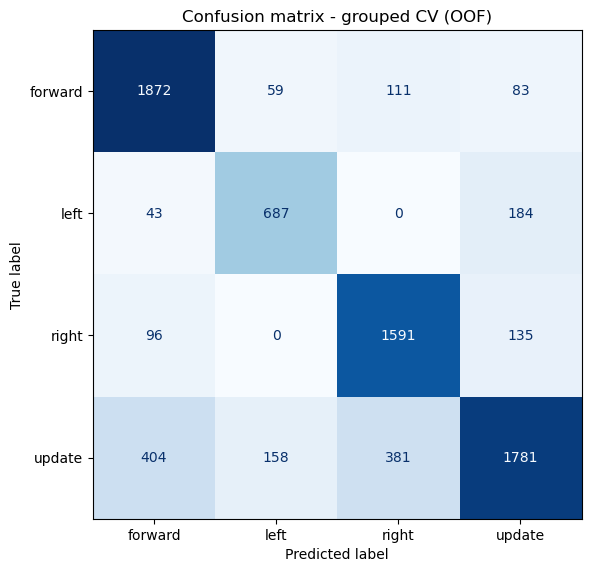

In [27]:
import matplotlib.pyplot as plt
plt.close("all")

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Confusion matrix - grouped CV (OOF)")
fig.tight_layout()
display(fig)
plt.show()


In [28]:
print(len(y_all), len(best_oof_pred))
print(labels_sorted)
print(cm)


7585 7585
['forward', 'left', 'right', 'update']
[[1872   59  111   83]
 [  43  687    0  184]
 [  96    0 1591  135]
 [ 404  158  381 1781]]


In [29]:
# ------------------------------------------------------------------
# ATTACH OUT-OF-FOLD PREDICTIONS TO FEATURE TABLE
# ------------------------------------------------------------------

oof_pred_df = all_feat_df.copy()
oof_pred_df["pred_label"] = best_oof_pred
oof_pred_df["is_correct"] = oof_pred_df["label"] == oof_pred_df["pred_label"]

class_to_index = {cls: i for i, cls in enumerate(all_classes)}
oof_pred_df["pred_confidence"] = [
    float(best_oof_prob[i, class_to_index[best_oof_pred[i]]]) for i in range(len(best_oof_pred))
]

oof_pred_csv = os.path.join(OUTPUT_DIR, "grouped_cv_oof_predictions.csv")
oof_pred_df.to_csv(oof_pred_csv, index=False)
print("Saved OOF predictions to:", oof_pred_csv)

display(oof_pred_df.head(20))


Saved OOF predictions to: /home/rodriguez/Documents/GitHub/habitat/habitat-lab/manual_operation/trained_navigator_outputs_cv_tolerant/grouped_cv_oof_predictions.csv


,source_log,raw_frame_id,target_keyframe,user_command,processed_command,label,row_type,bot_lost,rmse,tx,ty,tz,qw,qx,qy,qz,sim_score,pred_label,is_correct,pred_confidence
0,rep_dinning,0,0,forward,update_memory,update,selected_frame_update,False,7.971944e-16,-1.110223e-16,7.771561e-16,-8.881784e-16,-1.000000,7.793685e-17,-2.010076e-16,-9.748082e-17,1.000000,update,True,0.994720
1,rep_dinning,0,2,forward,forward,forward,selected_frame_duplicate_next_target,False,2.253966e-01,-1.104259e-02,2.779756e-02,1.710790e-01,-0.999988,3.831845e-03,2.790258e-03,1.237332e-03,0.932823,forward,True,0.919158
2,rep_dinning,1,2,forward,forward,forward,regular_motion,False,3.282183e-01,-5.060988e-03,6.372766e-03,1.106206e-01,0.999999,-1.198777e-03,1.591713e-04,5.196332e-04,0.950073,forward,True,0.674863
3,rep_dinning,2,2,forward,update_memory,update,selected_frame_update,False,8.112449e-16,4.440892e-16,-6.661338e-16,0.000000e+00,-1.000000,-0.000000e+00,2.964003e-16,2.879095e-16,1.000000,update,True,0.994720
4,rep_dinning,2,4,forward,forward,forward,selected_frame_duplicate_next_target,False,3.497174e-01,-7.351410e-02,1.119213e-03,1.754399e-01,-0.999957,1.179809e-03,9.028461e-03,-1.601200e-03,0.934189,forward,True,0.957218
5,rep_dinning,3,4,forward,forward,forward,regular_motion,False,3.007303e-01,8.243455e-03,-4.912237e-03,1.229194e-01,0.999999,5.139054e-04,1.587474e-03,1.882942e-04,0.947703,forward,True,0.732940
6,rep_dinning,4,4,forward,update_memory,update,selected_frame_update,False,9.682328e-16,1.110223e-16,1.387779e-15,-4.440892e-16,-1.000000,1.003338e-16,2.841699e-16,5.554516e-17,1.000000,update,True,0.994720
7,rep_dinning,4,6,forward,forward,forward,selected_frame_duplicate_next_target,False,3.790081e-01,-6.389276e-02,5.824745e-03,1.431000e-01,-0.999953,1.716753e-03,9.470675e-03,-1.208730e-03,0.915995,forward,True,0.895089
8,rep_dinning,5,6,forward,forward,forward,regular_motion,False,1.823603e-01,6.845055e-04,-4.691751e-03,9.659763e-02,-0.999997,-9.386327e-04,9.077370e-04,1.901982e-03,0.944848,forward,True,0.584606
9,rep_dinning,6,6,forward,update_memory,update,selected_frame_update,False,4.527719e-16,-2.220446e-16,3.608225e-16,0.000000e+00,1.000000,-0.000000e+00,-1.068240e-16,2.487997e-17,1.000000,update,True,0.986429


In [30]:
# ------------------------------------------------------------------
# VISUAL INSPECTION OF GOOD / BAD PREDICTIONS
# ------------------------------------------------------------------

def show_prediction_row(row: pd.Series, loaded_logs: Dict[str, LoadedLog]):
    raw_frame_id = int(row["raw_frame_id"])
    target_keyframe = int(row["target_keyframe"])
    log_obj = loaded_logs[row["source_log"]]

    observed_rgb = log_obj.rgb_frames[raw_frame_id]
    key_rgb = log_obj.rgb_frames[target_keyframe]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(observed_rgb)
    axes[0].set_title(f"Observed RGB | {row['source_log']} | frame {raw_frame_id}")
    axes[0].axis("off")

    axes[1].imshow(key_rgb)
    axes[1].set_title(f"Target key RGB | keyframe {target_keyframe}")
    axes[1].axis("off")

    title = (
        f"log={row['source_log']} | true={row['label']} | pred={row['pred_label']} | "
        f"confidence={row['pred_confidence']:.3f} | row_type={row['row_type']}"
    )
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    display(pd.DataFrame([row]))


def show_top_examples(df: pd.DataFrame, loaded_logs: Dict[str, LoadedLog], correct: bool = True, n: int = 3):
    subset = df[df["is_correct"] == correct].sort_values("pred_confidence", ascending=False).head(n)
    print(f"Showing {'correct' if correct else 'wrong'} examples: {len(subset)}")
    for _, row in subset.iterrows():
        show_prediction_row(row, loaded_logs)


In [31]:
# ------------------------------------------------------------------
# SOME GOOD PREDICTIONS
# ------------------------------------------------------------------

show_top_examples(oof_pred_df, all_loaded_logs, correct=True, n=4)


Showing correct examples: 4


,source_log,raw_frame_id,target_keyframe,user_command,processed_command,label,row_type,bot_lost,rmse,tx,ty,tz,qw,qx,qy,qz,sim_score,pred_label,is_correct,pred_confidence
7237,rep_bed_tv,36,40,forward,forward,forward,imperfect_retracing_early_switch,False,1.072027,-0.557299,-0.107445,0.13145,-0.997583,-0.009306,0.067882,-0.011571,0.874915,forward,True,0.999967


,source_log,raw_frame_id,target_keyframe,user_command,processed_command,label,row_type,bot_lost,rmse,tx,ty,tz,qw,qx,qy,qz,sim_score,pred_label,is_correct,pred_confidence
1907,rep_wc,286,290,forward,forward,forward,imperfect_retracing_early_switch,False,0.370278,0.08686,-0.147611,0.429544,0.999344,0.031059,0.017326,-0.006831,0.910229,forward,True,0.999872


,source_log,raw_frame_id,target_keyframe,user_command,processed_command,label,row_type,bot_lost,rmse,tx,ty,tz,qw,qx,qy,qz,sim_score,pred_label,is_correct,pred_confidence
7301,rep_bed_tv,165,170,right,right,right,imperfect_retracing_early_switch,False,0.289707,-0.016541,-0.009993,-0.029164,0.99635,0.000299,0.085345,0.00171,0.908512,right,True,0.999833


,source_log,raw_frame_id,target_keyframe,user_command,processed_command,label,row_type,bot_lost,rmse,tx,ty,tz,qw,qx,qy,qz,sim_score,pred_label,is_correct,pred_confidence
7305,rep_bed_tv,179,183,right,right,right,imperfect_retracing_early_switch,False,0.290191,-0.066577,-0.009809,-0.023993,0.998181,0.001476,0.06027,0.000352,0.912244,right,True,0.999772


In [32]:
# ------------------------------------------------------------------
# SOME BAD PREDICTIONS
# ------------------------------------------------------------------

show_top_examples(oof_pred_df, all_loaded_logs, correct=False, n=6)


Showing wrong examples: 6


,source_log,raw_frame_id,target_keyframe,user_command,processed_command,label,row_type,bot_lost,rmse,tx,ty,tz,qw,qx,qy,qz,sim_score,pred_label,is_correct,pred_confidence
1858,rep_wc,161,166,right,right,right,imperfect_retracing_early_switch,False,0.487205,0.09965,-0.044924,0.435267,0.999639,0.004745,0.026399,-0.001558,0.890833,forward,False,0.997038


,source_log,raw_frame_id,target_keyframe,user_command,processed_command,label,row_type,bot_lost,rmse,tx,ty,tz,qw,qx,qy,qz,sim_score,pred_label,is_correct,pred_confidence
4738,rep_bed-to-lavatory,40,43,forward,forward,forward,imperfect_retracing_early_switch,False,0.596699,-0.103411,0.004144,0.009316,-0.998626,0.001863,0.052327,-0.002039,0.917,left,False,0.99408


,source_log,raw_frame_id,target_keyframe,user_command,processed_command,label,row_type,bot_lost,rmse,tx,ty,tz,qw,qx,qy,qz,sim_score,pred_label,is_correct,pred_confidence
7236,rep_bed_tv,34,37,left,left,left,imperfect_retracing_early_switch,False,0.768751,-0.262285,0.040032,0.039407,-0.998873,0.006493,0.046996,-0.001459,0.892579,forward,False,0.991105


,source_log,raw_frame_id,target_keyframe,user_command,processed_command,label,row_type,bot_lost,rmse,tx,ty,tz,qw,qx,qy,qz,sim_score,pred_label,is_correct,pred_confidence
4736,rep_bed-to-lavatory,34,38,forward,forward,forward,imperfect_retracing_early_switch,False,1.053084,-0.385441,0.049327,0.018714,-0.995088,0.01431,0.097576,-0.008585,0.889732,left,False,0.989453


,source_log,raw_frame_id,target_keyframe,user_command,processed_command,label,row_type,bot_lost,rmse,tx,ty,tz,qw,qx,qy,qz,sim_score,pred_label,is_correct,pred_confidence
460,rep_dinning,70,71,forward,update_memory,update,near_keyframe_tolerance_update_before,False,0.65864,-0.148976,-0.03045,0.180267,-0.999891,-0.00321,0.013535,-0.005045,0.93763,forward,False,0.986955


,source_log,raw_frame_id,target_keyframe,user_command,processed_command,label,row_type,bot_lost,rmse,tx,ty,tz,qw,qx,qy,qz,sim_score,pred_label,is_correct,pred_confidence
5229,rep_left_bed,75,79,forward,forward,forward,imperfect_retracing_early_switch,False,0.366024,-0.008283,0.014474,0.11022,-0.998602,0.00156,0.052806,0.001545,0.905812,left,False,0.982341


In [33]:
# ------------------------------------------------------------------
# MISCLASSIFICATION SUMMARY
# ------------------------------------------------------------------

mis_df = oof_pred_df[~oof_pred_df["is_correct"]].copy()
if len(mis_df) > 0:
    display(mis_df[[
        "source_log",
        "raw_frame_id",
        "target_keyframe",
        "label",
        "pred_label",
        "pred_confidence",
        "row_type",
        "rmse",
        "sim_score",
        "tx", "ty", "tz"
    ]].head(30))
else:
    print("No misclassifications in grouped CV OOF predictions.")


,source_log,raw_frame_id,target_keyframe,label,pred_label,pred_confidence,row_type,rmse,sim_score,tx,ty,tz
25,rep_dinning,18,20,forward,right,0.666895,regular_motion,0.201376,0.950887,-0.032018,0.002620,0.081761
26,rep_dinning,19,20,right,update,0.631429,regular_motion,0.231973,0.964037,0.040147,0.003446,0.001049
33,rep_dinning,24,27,forward,right,0.793377,regular_motion,0.091492,0.936795,0.005136,-0.002827,0.097007
49,rep_dinning,35,36,forward,update,0.681430,regular_motion,0.478096,0.963527,0.056956,0.022308,0.066017
51,rep_dinning,36,39,forward,right,0.748747,selected_frame_duplicate_next_target,0.562724,0.927210,-0.051821,-0.017583,0.165148
66,rep_dinning,46,47,right,update,0.478793,selected_frame_duplicate_next_target,0.351433,0.925420,0.028895,-0.003893,0.019342
69,rep_dinning,48,49,right,update,0.498168,regular_motion,0.498790,0.931202,-0.002806,0.008704,-0.036489
74,rep_dinning,51,52,right,update,0.679434,selected_frame_duplicate_next_target,0.456193,0.936412,0.044155,-0.006290,-0.041578
82,rep_dinning,56,57,right,update,0.630427,regular_motion,0.566714,0.952696,0.013215,-0.013216,-0.048403
93,rep_dinning,62,65,forward,right,0.912893,selected_frame_duplicate_next_target,0.567216,0.932986,-0.116118,-0.014315,0.088517


In [34]:
# ------------------------------------------------------------------
# MANUAL INSPECTION OF A SINGLE OOF ROW
# Edit row_index as needed.
# ------------------------------------------------------------------

row_index = 0
show_prediction_row(oof_pred_df.iloc[row_index], all_loaded_logs)


,source_log,raw_frame_id,target_keyframe,user_command,processed_command,label,row_type,bot_lost,rmse,tx,ty,tz,qw,qx,qy,qz,sim_score,pred_label,is_correct,pred_confidence
0,rep_dinning,0,0,forward,update_memory,update,selected_frame_update,False,7.971944e-16,-1.110223e-16,7.771561e-16,-8.881784e-16,-1.0,7.793685e-17,-2.010076e-16,-9.748082e-17,1.0,update,True,0.99472
